In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
df = pd.read_csv("/content/archive (2).zip")

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

/tmp/ipykernel_9223/3083128645.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [ ]:
# Use Adjusted Close as the time series, enforce business-day frequency
X = df["Close"].asfreq("B")
X_log = np.log(X)
X_log_diff = X_log.diff().dropna()

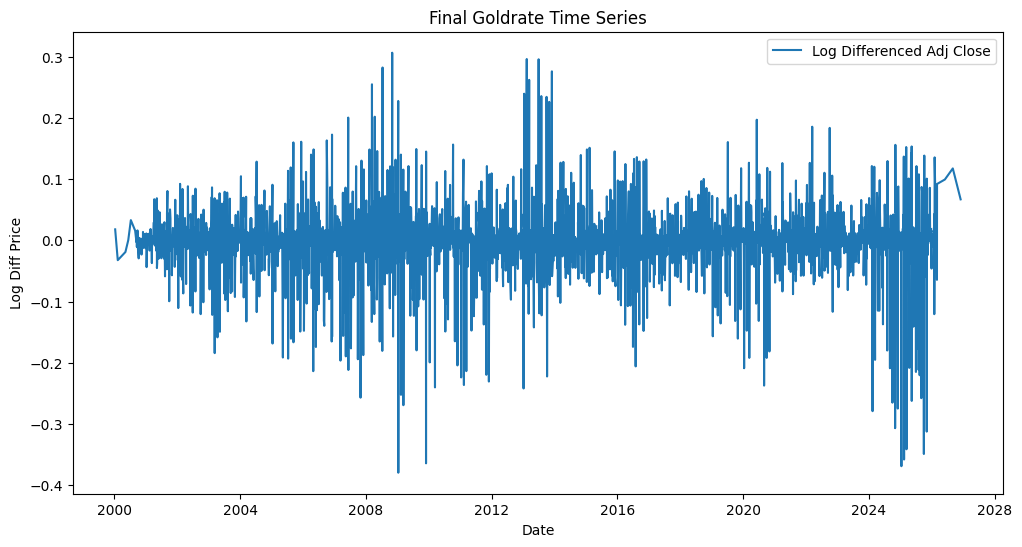

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(X_log_diff, label="Log Differenced Adj Close")
plt.title("Final Goldrate Time Series")
plt.xlabel("Date")
plt.ylabel("Log Diff Price")
plt.legend()
plt.show()

In [ ]:
result = adfuller(X_log_diff)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -16.868057445958065
p-value: 1.0865406764665926e-29


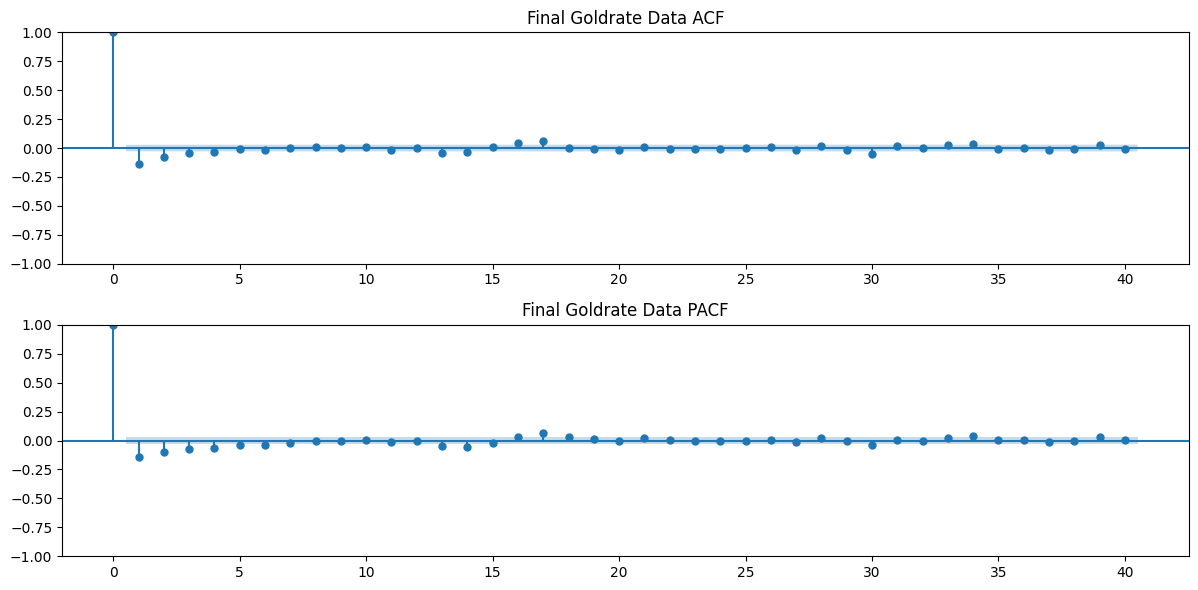

In [ ]:
# Plot ACF and PACF
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plot_acf(X_log_diff, lags=40, ax=plt.gca())
plt.title("Final Goldrate Data ACF")
plt.subplot(2,1,2)
plot_pacf(X_log_diff, lags=40, ax=plt.gca())
plt.title("Final Goldrate Data PACF")
plt.tight_layout()
plt.show()

In [ ]:
arma11_model = ARIMA(X_log_diff, order=(1, 0, 1)).fit()
print("ARMA(1,1) Summary:\n", arma11_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARMA(1,1) Summary:
                                SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 4874
Model:                 ARIMA(1, 0, 1)   Log Likelihood                8370.635
Date:                Sat, 02 May 2026   AIC                         -16733.271
Time:                        03:19:43   BIC                         -16707.304
Sample:                             0   HQIC                        -16724.158
                               - 4874                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0007      0.000     -1.940      0.052      -0.002    7.87e-06
ar.L1          0.5711      0.038     14.978      0.000       0.496       0.646
ma.L1         -0.7459      0.034

In [ ]:
phi1 = arma11_model.params.get('ar.L1', 0)
theta1 = arma11_model.params.get('ma.L1', 0)
ar1 = np.array([1, -phi1])
ma1 = np.array([1, theta1])
arma11_sim = ArmaProcess(ar1, ma1).generate_sample(nsample=200)

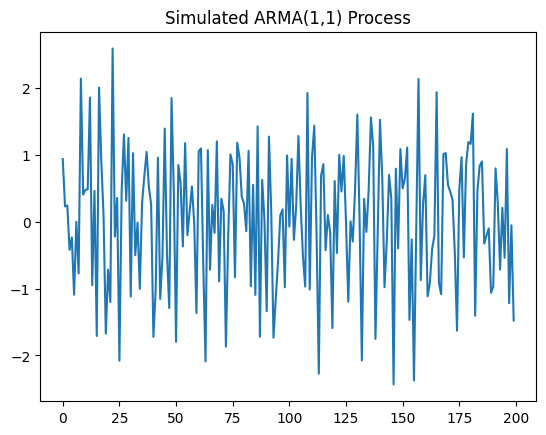

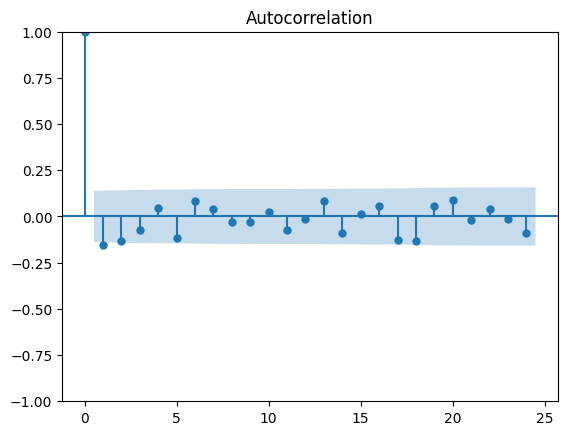

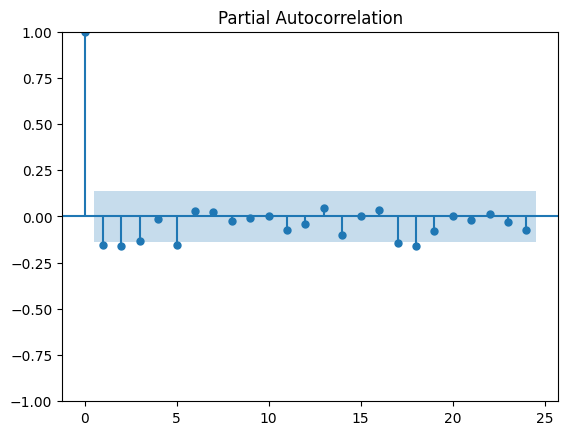

In [ ]:
plt.plot(arma11_sim)
plt.title("Simulated ARMA(1,1) Process")
plt.show()
plot_acf(arma11_sim)
plt.show()
plot_pacf(arma11_sim)
plt.show()

In [ ]:
arma22_model = ARIMA(X_log_diff, order=(2, 0, 2)).fit()
print("ARMA(2,2) Summary:\n", arma22_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARMA(2,2) Summary:
                                SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 4874
Model:                 ARIMA(2, 0, 2)   Log Likelihood                8370.592
Date:                Sat, 02 May 2026   AIC                         -16729.183
Time:                        03:22:22   BIC                         -16690.233
Sample:                             0   HQIC                        -16715.514
                               - 4874                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0007      0.000     -1.954      0.051      -0.001     2.1e-06
ar.L1         -0.1745      2.382     -0.073      0.942      -4.843       4.494
ar.L2          0.4418      1.420

In [ ]:
phi1 = arma22_model.params.get('ar.L1', 0)
phi2 = arma22_model.params.get('ar.L2', 0)
theta1 = arma22_model.params.get('ma.L1', 0)
theta2 = arma22_model.params.get('ma.L2', 0)
ar2 = np.array([1, -phi1, -phi2])
ma2 = np.array([1, theta1, theta2])
arma22_sim = ArmaProcess(ar2, ma2).generate_sample(nsample=200)

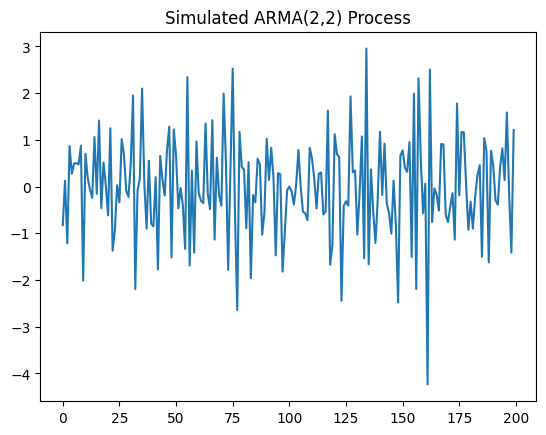

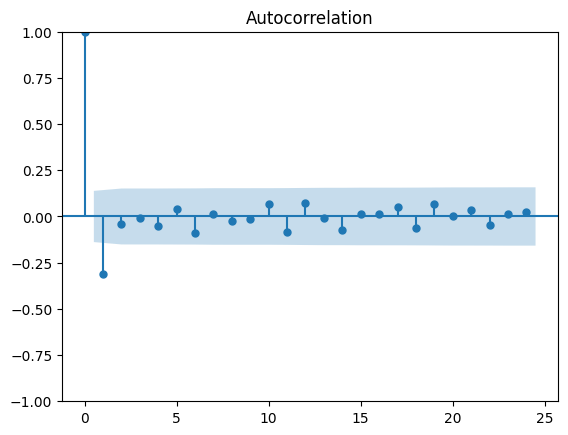

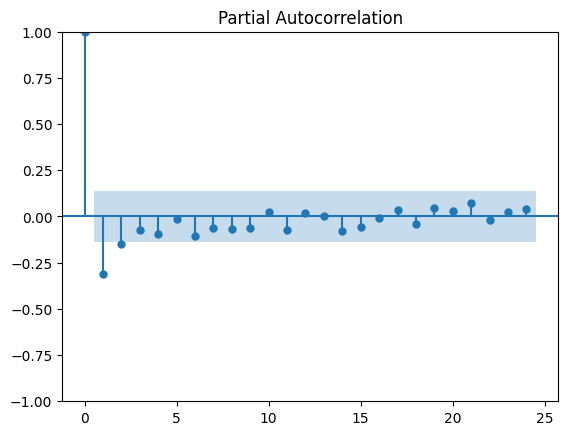

In [ ]:
plt.plot(arma22_sim)
plt.title("Simulated ARMA(2,2) Process")
plt.show()
plot_acf(arma22_sim)
plt.show()
plot_pacf(arma22_sim)
plt.show()